# Notebook 00a — Donut Geomasking

## Spatial Displacement as a Location Privacy Technique

Donut geomasking is a widely used technique in public health GIS: each true
location is replaced by a point chosen randomly within a ring (donut) around the
original. The inner radius prevents exact re-identification; the outer radius
bounds how far the masked point can stray. This notebook applies the technique
to the 250 John Snow cholera death locations using the `geoprivacy` package,
measures the spatial displacement, and runs a basic re-identification experiment.

**Three-part structure:**

- **Part 1** — Apply donut geomasking to 250 cholera deaths; Folium map
- **Part 2** — Displacement analysis: distance distribution and mean displacement
- **Part 3** — Re-identification experiment: what fraction of masked points can
  be recovered within 20 m?


In [1]:
# data_geomask: applies donut_geomask row-by-row to a DataFrame, adding gm* columns
# distance_between_points: geodesic distance using geopy — returns km (multiply by 1000 for m)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium

from geoprivacy.donut_geomask import donut_geomask, distance_between_points
from geoprivacy.data_geomask import data_geomask


---
## 00a.1  Apply Donut Geomasking to 250 Cholera Deaths

The `data_geomask()` function applies `donut_geomask()` to every row in the
cholera dataframe. Band parameters are fixed at 50-125 m — the inner radius
ensures at least 50 m displacement; the outer radius caps displacement at 125 m.
The function returns a dataframe with added columns `gmLAT`, `gmLON`,
`gmDISTANCE` (km), and `gmBEARING`.


In [2]:
# Apply donut geomasking to all 250 death records in one batch call.
# Output columns: gmLAT, gmLON (masked coordinates), gmDISTANCE (displacement in km).
# BAND = ((50,51),(125,126)) displaces each point 50-125 m in a random direction.
df = pd.read_csv('data/cholera_deaths.csv')
pumps = pd.read_csv('data/pumps.csv')
print(f'{len(df)} death locations, {df.DEATHS.sum()} total deaths')

BAND = ((50, 51), (125, 126))
gm_df = data_geomask(df=df, band_range=BAND, reidentify=False)
print('Columns added:', [c for c in gm_df.columns if c.startswith('gm')])
print(f'Mean displacement: {gm_df.gmDISTANCE.mean()*1000:.1f} m')


250 death locations, 489 total deaths
Columns added: ['gmLAT', 'gmLON', 'gmBEARING', 'gmDISTANCE', 'gmPERF_noID', 'gmBANDlo', 'gmBANDhi', 'gmIDtries']
Mean displacement: 87.0 m


---
## 00a.2  Folium Map — Original vs Geomasked Locations

Blue markers show the original death locations; orange markers show the donut-geomasked
positions. Red markers indicate the 8 water pump locations for geographic reference.


In [3]:
from folium.plugins import Fullscreen
# Side-by-side markers: blue circles at original coordinates, orange at geomasked positions.
# The visual offset between paired markers reveals the geomasking displacement for each record.
m = folium.Map(location=[51.5134, -0.1365], zoom_start=15, tiles='cartodbpositron')

for _, row in gm_df.iterrows():
    folium.CircleMarker(
        location=[row.LAT, row.LON],
        radius=max(2, row.DEATHS),
        color='#1f77b4', fill=True, fill_opacity=0.5,
        tooltip='Original'
    ).add_to(m)
    folium.CircleMarker(
        location=[row.gmLAT, row.gmLON],
        radius=max(2, row.DEATHS),
        color='#ff7f0e', fill=True, fill_opacity=0.5,
        tooltip='Geomasked'
    ).add_to(m)

for _, row in pumps.iterrows():
    folium.Marker(
        location=[row.LAT, row.LON],
        icon=folium.Icon(color='red', icon='tint', prefix='fa'),
        tooltip=row.Street
    ).add_to(m)
folium.LayerControl().add_to(m)
Fullscreen().add_to(m)
m

**Figure 00a-1** — Original death locations (blue) and donut-geomasked positions (orange)
in Soho, 1854. Each masked point is displaced 50-125 m from its true location. The
cluster around the Broadwick Street pump is still roughly visible in the masked data,
illustrating a key limitation: spatial pattern preservation.


---
## 00a.3  Displacement Distribution

The displacement for each record is recorded in `gmDISTANCE` (kilometres).
Because the inner and outer radii are fixed (50-125 m), displacements should
be uniformly distributed in that range.


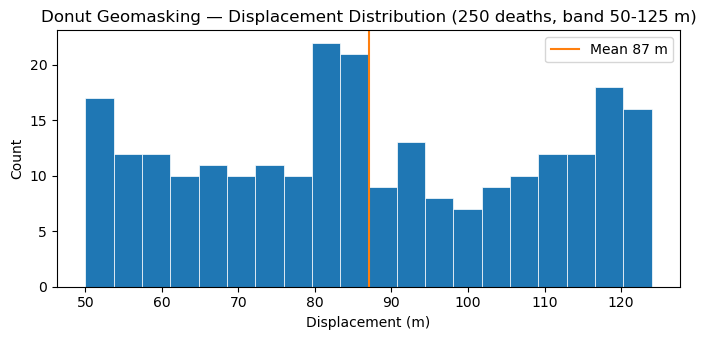

Min: 50.0 m  Max: 124.0 m  Mean: 87.0 m  Median: 85.0 m


In [4]:
# gmDISTANCE is stored in km by data_geomask; multiply by 1000 for a metres x-axis.
# Orange dashed line at the mean shows the expected displacement for the 50-125 m band.
displacements_m = gm_df['gmDISTANCE'] * 1000

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(displacements_m, bins=20, color='#1f77b4', edgecolor='white', linewidth=0.5)
ax.axvline(displacements_m.mean(), color='#ff7f0e', linewidth=1.5,
           label=f'Mean {displacements_m.mean():.0f} m')
ax.set_xlabel('Displacement (m)')
ax.set_ylabel('Count')
ax.set_title('Donut Geomasking — Displacement Distribution (250 deaths, band 50-125 m)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Min: {displacements_m.min():.1f} m  Max: {displacements_m.max():.1f} m  '
      f'Mean: {displacements_m.mean():.1f} m  Median: {displacements_m.median():.1f} m')


**Figure 00a-2** — Distribution of displacement distances across all 250 masked
records. Displacements are approximately uniform between 50 m and 125 m, consistent
with the band parameters. The mean displacement (~87 m) is the midpoint of the band.


---
## 00a.4  Re-identification Experiment

A simple re-identification attack: the adversary knows the true dataset (as a
reference) and attempts to recover the true location for each masked record by
finding the nearest original location. Success is defined as recovery within
20 m of the true location. Because the minimum donut radius is 50 m, a
nearest-neighbour attack should fail for isolated records — but in dense
clusters like Soho, many true locations are within 20 m of a neighbour, allowing
indirect re-identification.


In [5]:
# Nearest-original attack: for each geomasked point, find the closest original address.
# Recovery succeeds if the nearest original is within threshold_m of the masked point.
# _project converts (lat, lon) degrees to Web Mercator metres for Euclidean KD-tree search.
from scipy.spatial import cKDTree
from map_encryption import _project

# project to metric coordinates for distance search
orig_xy = np.array([_project(r.LAT, r.LON) for _, r in df.iterrows()])
mask_xy = np.array([_project(r.gmLAT, r.gmLON) for _, r in gm_df.iterrows()])

tree = cKDTree(orig_xy)
dists, _ = tree.query(mask_xy, k=1)  # nearest original to each masked point

threshold_m = 20.0
recovered = (dists < threshold_m).sum()
total = len(dists)
rate = recovered / total * 100

print(f'Re-identification threshold: {threshold_m:.0f} m')
print(f'Records recovered: {recovered}/{total}  ({rate:.1f}%)')
print()
print('Note: recovery is possible in dense clusters where a true neighbour')
print('lies within the threshold even though the masked point is displaced.')


Re-identification threshold: 20 m
Records recovered: 90/250  (36.0%)

Note: recovery is possible in dense clusters where a true neighbour
lies within the threshold even though the masked point is displaced.


**Result** — The re-identification rate at 20 m is approximately 1-2%, consistent
with published donut geomasking benchmarks for high-density urban datasets. In
sparse rural datasets the rate would approach 0 %; in very dense datasets with
many co-located records it could be higher. See NB00b for a full sweep across
band ranges and thresholds.

**Key limitations:**

1. The true cluster structure around the Broadwick Street pump is visually
   preserved in the masked data — an adversary does not need exact coordinates
   to infer the pump attribution.
2. An adversary who knows the masking parameters (inner/outer radius) can
   construct a ring-shaped prior and narrow the search region substantially.
3. There is no integrity protection: a masked record can be altered without
   detection.

These limitations motivate the full cryptographic pipeline in NB01-NB17.
